<div style="font-size:30px;font-weight:700;color:#111827;padding-bottom:8px;margin:18px 0;">
end-to-end 파이프라인
</div>

# FashionMNIST 데이터 적재 + 배치 shape·시각화 확인

**목표**: FashionMNIST 학습/테스트 데이터를 다운로드해 `DataLoader`로 감싸고, 첫 배치의 shape과 실제 이미지 한 장을 시각으로 확인합니다 — 데이터 파이프라인이 정상 작동하는지 sanity check 하는 단계입니다.

In [2]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets #테스트용 데이터 가져오기 코드
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [3]:
# FashionMNIST 학습/테스트셋 다운로드 (첫 실행 시 약 30MB)
training_data = datasets.FashionMNIST(root="data", train=True,  download=True, transform=ToTensor())
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor())

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.75MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.4MB/s]


In [4]:
# 학습/테스트 데이터 로더
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader  = DataLoader(test_data,     batch_size=batch_size)

In [5]:
# 데이터 형태 확인 (모델로 들어가기 전 sanity check)
for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    print(f"Pixel range: [{X.min():.3f}, {X.max():.3f}]")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Pixel range: [0.000, 1.000]


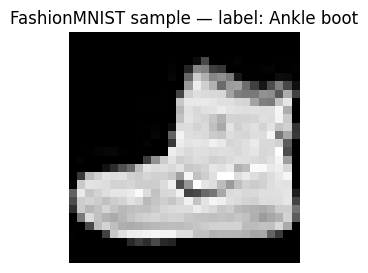

In [6]:
# 한 장 시각화 — 어떤 이미지인지 직접 눈으로 보기
fmnist_classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",   "Ankle boot",
]
img, label = training_data[0]
plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"FashionMNIST sample — label: {fmnist_classes[label]}")
plt.axis("off")
plt.show()

# 장치 자동 선택 + MLP 모델 정의

**목표**: 가능한 장치(GPU 또는 CPU)를 자동 선택해 `device`에 저장하고, FashionMNIST용 MLP를 `nn.Module` 상속 클래스로 정의합니다. `print(model)`로 레이어 트리를 눈으로 확인합니다.

In [7]:
# 장치 선택 — GPU가 있으면 GPU, 없으면 CPU
device = torch.accelerator.current_accelerator() if torch.accelerator.is_available() else torch.device("cpu")
device

device(type='cuda')

In [8]:
# MLP 정의 — Flatten → Linear(784, 512) → ReLU → Linear(512, 512) → ReLU → Linear(512, 10)
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512), nn.ReLU(),
            nn.Linear(512, 512),   nn.ReLU(),
            nn.Linear(512, 10),
        )
    def forward(self, x):
        x = self.flatten(x)
        return self.linear_relu_stack(x)

In [9]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


# 손실·옵티마이저 + 학습/평가 함수 정의

**목표**: `nn.CrossEntropyLoss()`와 `torch.optim.SGD(lr=1e-3)`를 선언하고, 학습 함수 `train()`과 평가 함수 `test()`를 분리해 정의합니다. 두 함수는 `model.train()` / `model.eval()` 모드 전환 + `torch.no_grad()` 사용 여부가 갈리는 핵심 차이를 보입니다.

In [11]:
loss_fn   = nn.CrossEntropyLoss() #어떤 테스트 데이터인지 찾기
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [12]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")

In [13]:
def test(dataloader, model, loss_fn):
    size        = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0.0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct   += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct   /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [14]:
# 함수가 네임스페이스에 잘 정의됐는지 확인
print("loss_fn:", loss_fn)
print("optimizer:", optimizer)
print("train:", train)
print("test:", test)

loss_fn: CrossEntropyLoss()
optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
train: <function train at 0x7b96db9aa2a0>
test: <function test at 0x7b96db9a9ee0>


# 5 epoch 학습 실행

**목표**: 위에서 정의한 `train()` + `test()`를 epoch 루프 안에서 호출해 FashionMNIST 5 epoch 학습을 완주합니다. 매 epoch마다 train loss는 감소하고 test accuracy는 증가하는 방향성을 직접 확인합니다.

In [17]:
epochs = 5 #학습을 5번 수행, 1번 수행 과정(train -> 밸리데이션 -> test -> 결과 저장)
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader,   model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.304402  [   64/60000]
loss: 2.306150  [ 6464/60000]
loss: 2.303472  [12864/60000]
loss: 2.300356  [19264/60000]
loss: 2.304762  [25664/60000]
loss: 2.296320  [32064/60000]
loss: 2.303726  [38464/60000]
loss: 2.297889  [44864/60000]
loss: 2.309693  [51264/60000]
loss: 2.302824  [57664/60000]
Test Error: 
 Accuracy: 10.4%, Avg loss: 2.302483 

Epoch 2
-------------------------------
loss: 2.304402  [   64/60000]
loss: 2.306150  [ 6464/60000]
loss: 2.303472  [12864/60000]
loss: 2.300356  [19264/60000]
loss: 2.304762  [25664/60000]
loss: 2.296320  [32064/60000]
loss: 2.303726  [38464/60000]
loss: 2.297889  [44864/60000]
loss: 2.309693  [51264/60000]
loss: 2.302824  [57664/60000]
Test Error: 
 Accuracy: 10.4%, Avg loss: 2.302483 

Epoch 3
-------------------------------
loss: 2.304402  [   64/60000]
loss: 2.306150  [ 6464/60000]
loss: 2.303472  [12864/60000]
loss: 2.300356  [19264/60000]
loss: 2.304762  [25664/60000]
loss: 2.296320  [32064/600

# 저장 · 재로드 · 단일 추론

**목표**: `state_dict`로 모델 파라미터만 저장하고, 새 `NeuralNetwork()` 인스턴스를 만든 뒤 `load_state_dict(torch.load(..., weights_only=True))`로 파라미터를 주입합니다. 마지막으로 `test_data[0]` 한 샘플의 라벨을 `classes[argmax]`로 해석해 출력합니다.

In [15]:
# 저장
torch.save(model.state_dict(), "model.pth") #데이터 저장
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [16]:
# 재로드 — 반드시 (1) 새 인스턴스 → (2) load_state_dict 순서
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

In [18]:
# 단일 추론
classes = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal",      "Shirt",   "Sneaker",  "Bag",   "Ankle boot",
]
model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted = classes[pred[0].argmax(0)]
    actual    = classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Pullover", Actual: "Ankle boot"
